Episode 10000, average return over last 10000: -0.3419
Episode 20000, average return over last 10000: -0.2798
Episode 30000, average return over last 10000: -0.2419
Episode 40000, average return over last 10000: -0.2176
Episode 50000, average return over last 10000: -0.2090
Episode 60000, average return over last 10000: -0.1879
Episode 70000, average return over last 10000: -0.1743
Episode 80000, average return over last 10000: -0.1522
Episode 90000, average return over last 10000: -0.1676
Episode 100000, average return over last 10000: -0.1375
Episode 110000, average return over last 10000: -0.1330
Episode 120000, average return over last 10000: -0.1601
Episode 130000, average return over last 10000: -0.1313
Episode 140000, average return over last 10000: -0.1221
Episode 150000, average return over last 10000: -0.1384
Episode 160000, average return over last 10000: -0.1325
Episode 170000, average return over last 10000: -0.1303
Episode 180000, average return over last 10000: -0.1295
E

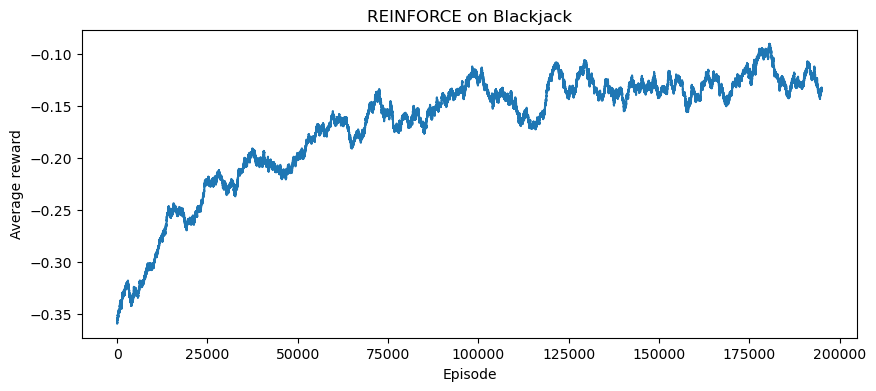

In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Create the Blackjack environment
env = gym.make("Blackjack-v1", natural=False, sab=False)

# State in Blackjack-v1 is:
#   (player_sum, dealer_showing, usable_ace)
# Action space:
#   0 = stick
#   1 = hit

# Policy parameter table:
# theta[player_sum, dealer_showing, usable_ace, action]
#
# We use a softmax policy:
#   pi(a|s) = exp(theta[s,a]) / sum_a' exp(theta[s,a'])
#
# The table is slightly oversized for convenience:
# - player_sum can go up to about 31 in indexing safety
# - dealer_showing is 1,...,10
# - usable_ace is 0 or 1
# - action is 0 or 1
theta = np.zeros((32, 11, 2, 2), dtype=np.float64)

def softmax(x):
    """
    Compute softmax probabilities from a length-2 preference vector x.

    Subtracting np.max(x) improves numerical stability.
    """
    z = x - np.max(x)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

def get_probs(state):
    """
    Return policy probabilities pi(.|state) under current theta.
    """
    player, dealer, usable = state
    return softmax(theta[player, dealer, int(usable)])

def sample_action(state):
    """
    Sample an action from the current stochastic policy.
    """
    probs = get_probs(state)
    return np.random.choice([0, 1], p=probs)

def generate_episode(env):
    """
    Generate one full episode using the current policy.

    Returns:
        states  : list of visited states s_t
        actions : list of actions a_t
        rewards : list of rewards r_{t+1}
    """
    states = []
    actions = []
    rewards = []

    state, _ = env.reset()
    done = False

    while not done:
        # Sample action from current policy
        action = sample_action(state)

        # Take one step in the environment
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Store transition information
        states.append(state)
        actions.append(action)
        rewards.append(reward)

        # Move to next state
        state = next_state

    return states, actions, rewards

def compute_returns(rewards, gamma=1.0):
    """
    Compute Monte Carlo return:
        G_t = r_{t+1} + gamma r_{t+2} + gamma^2 r_{t+3} + ...

    For episodic Blackjack with gamma=1, this is just the remaining sum
    of rewards from each time step onward.
    """
    G = 0.0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()
    return returns

# Learning rate
alpha = 0.01

# Discount factor
gamma = 1.0

# Number of training episodes
n_episodes = 200000

# Store total reward from each episode for monitoring
episode_returns = []

for ep in range(n_episodes):
    # Sample one episode under the current policy
    states, actions, rewards = generate_episode(env)

    # Compute return G_t for each visited time step
    returns = compute_returns(rewards, gamma=gamma)

    # Total reward of this episode
    # In Blackjack this is usually the terminal payoff: -1, 0, or 1
    episode_returns.append(sum(rewards))

    # REINFORCE update:
    # theta <- theta + alpha * G_t * grad log pi(a_t | s_t)
    #
    # For softmax with preferences theta[s, :],
    # grad wrt theta[s,k] is:
    #   1{k=a_t} - pi(k|s_t)
    for state, action, G in zip(states, actions, returns):
        player, dealer, usable = state
        usable = int(usable)

        # Current action probabilities at this state
        probs = get_probs(state)

        # Gradient ascent on theta[player, dealer, usable, :]
        for k in range(2):
            indicator = 1.0 if k == action else 0.0
            theta[player, dealer, usable, k] += alpha * G * (indicator - probs[k])

    # Print moving average every 10,000 episodes
    if (ep + 1) % 10000 == 0:
        avg_return = np.mean(episode_returns[-10000:])
        print(f"Episode {ep+1}, average return over last 10000: {avg_return:.4f}")

env.close()

# Plot a smoothed learning curve
plt.figure(figsize=(10,4))
window = 5000
smoothed = np.convolve(episode_returns, np.ones(window)/window, mode='valid')
plt.plot(smoothed)
plt.xlabel("Episode")
plt.ylabel("Average reward")
plt.title("REINFORCE on Blackjack")
plt.show()

In [7]:
import numpy as np

def greedy_action(state):
    probs = get_probs(state)
    return int(np.argmax(probs))

def sample_action_from_policy(state):
    probs = get_probs(state)
    return int(np.random.choice([0, 1], p=probs))

def uniform_action(state):
    # Ignore the state and choose each action with probability 1/2
    return int(np.random.choice([0, 1]))

def evaluate_policy(env, n_eval_episodes=100000, policy_type="greedy"):
    returns = []

    for _ in range(n_eval_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0.0

        while not done:
            if policy_type == "greedy":
                action = greedy_action(state)
            elif policy_type == "stochastic":
                action = sample_action_from_policy(state)
            elif policy_type == "uniform":
                action = uniform_action(state)
            else:
                raise ValueError("policy_type must be 'greedy', 'stochastic', or 'uniform'")

            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        returns.append(total_reward)

    returns = np.array(returns, dtype=np.float64)

    avg_return = returns.mean()
    win_rate = np.mean(returns > 0)
    draw_rate = np.mean(returns == 0)
    loss_rate = np.mean(returns < 0)

    return {
        "avg_return": avg_return,
        "win_rate": win_rate,
        "draw_rate": draw_rate,
        "loss_rate": loss_rate,
        "returns": returns,
    }

In [9]:
eval_env = gym.make("Blackjack-v1", natural=False, sab=False)

greedy_results = evaluate_policy(eval_env, n_eval_episodes=10000, policy_type="greedy")
stochastic_results = evaluate_policy(eval_env, n_eval_episodes=10000, policy_type="stochastic")
uniform_results = evaluate_policy(eval_env, n_eval_episodes=10000, policy_type="uniform")
eval_env.close()

print("Greedy policy evaluation")
print(f"Average return: {greedy_results['avg_return']:.4f}")
print(f"Win rate:       {greedy_results['win_rate']:.4f}")
print(f"Draw rate:      {greedy_results['draw_rate']:.4f}")
print(f"Loss rate:      {greedy_results['loss_rate']:.4f}")

print("\nStochastic policy evaluation")
print(f"Average return: {stochastic_results['avg_return']:.4f}")
print(f"Win rate:       {stochastic_results['win_rate']:.4f}")
print(f"Draw rate:      {stochastic_results['draw_rate']:.4f}")
print(f"Loss rate:      {stochastic_results['loss_rate']:.4f}")

print("\nUniform policy evaluation")
print(f"Average return: {uniform_results['avg_return']:.4f}")
print(f"Win rate:       {uniform_results['win_rate']:.4f}")
print(f"Draw rate:      {uniform_results['draw_rate']:.4f}")
print(f"Loss rate:      {uniform_results['loss_rate']:.4f}")

Greedy policy evaluation
Average return: -0.0537
Win rate:       0.4300
Draw rate:      0.0863
Loss rate:      0.4837

Stochastic policy evaluation
Average return: -0.0938
Win rate:       0.4151
Draw rate:      0.0760
Loss rate:      0.5089

Uniform policy evaluation
Average return: -0.3894
Win rate:       0.2846
Draw rate:      0.0414
Loss rate:      0.6740
